In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

columns = [
    'timestamp',
    'city',
    'current_temp',
    'feels_like',
    'humidity',
    'wind_speed',
    'weather_description',
    'temp_min',
    'temp_max',
    'pressure',
    'country',
    'visibility'
]

df = pd.read_csv(
    "/home/Aqib/Desktop/weather_forecast/weather_data.csv",
    header=None,
    names=columns
)

df.head()

,timestamp,city,current_temp,feels_like,humidity,wind_speed,weather_description,temp_min,temp_max,pressure,country,visibility
0,2026-05-07 16:59:05,Mumbai,33,40,62,6.69,haze,32,33,1005,IN,4500
1,2026-05-07 16:59:05,Delhi,30,29,37,7.72,clear sky,30,30,1006,IN,6000
2,2026-05-07 16:59:05,Bengaluru,32,33,43,7.15,scattered clouds,31,33,1004,IN,8000
3,2026-05-07 16:59:05,Hyderabad,35,36,34,3.60,scattered clouds,35,36,1004,IN,6000
4,2026-05-07 16:59:06,Ahmedabad,40,38,15,3.60,smoke,40,40,1003,IN,5000


In [4]:
print("Shape :", df.shape)

print("\nColumns :")
print(df.columns)

print("\nInfo :")
print(df.info())

print("\nStatistical Summary :")
display(df.describe())

print("\nMissing Values :")
print(df.isnull().sum())

Shape : (847, 12)

Columns :
Index(['timestamp', 'city', 'current_temp', 'feels_like', 'humidity',
       'wind_speed', 'weather_description', 'temp_min', 'temp_max', 'pressure',
       'country', 'visibility'],
      dtype='object')

Info :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp            847 non-null    object 
 1   city                 847 non-null    object 
 2   current_temp         847 non-null    int64  
 3   feels_like           847 non-null    int64  
 4   humidity             847 non-null    int64  
 5   wind_speed           847 non-null    float64
 6   weather_description  847 non-null    object 
 7   temp_min             847 non-null    int64  
 8   temp_max             847 non-null    int64  
 9   pressure             847 non-null    int64  
 10  country              847 non-null    object 
 11

,current_temp,feels_like,humidity,wind_speed,temp_min,temp_max,pressure,visibility
count,847.000000,847.000000,847.000000,847.000000,847.000000,847.000000,847.000000,847.000000
mean,31.879575,32.547816,41.602125,3.863707,31.806375,31.920897,1006.525384,6812.632822
std,4.553298,4.899922,21.025115,2.171200,4.536201,4.546542,2.169312,2625.564181
min,16.000000,14.000000,5.000000,0.000000,16.000000,16.000000,1001.000000,1600.000000
25%,29.500000,30.000000,25.000000,2.060000,29.000000,30.000000,1005.000000,5000.000000
50%,32.000000,33.000000,37.000000,3.600000,32.000000,32.000000,1006.000000,6000.000000
75%,34.000000,36.000000,59.000000,5.140000,34.000000,34.000000,1008.000000,10000.000000
max,43.000000,47.000000,100.000000,11.750000,43.000000,43.000000,1015.000000,10000.000000



Missing Values :
timestamp              0
city                   0
current_temp           0
feels_like             0
humidity               0
wind_speed             0
weather_description    0
temp_min               0
temp_max               0
pressure               0
country                0
visibility             0
dtype: int64


In [5]:
from ydata_profiling import ProfileReport

In [6]:
prof = ProfileReport(df)
prof.to_file(output_file='/home/Aqib/Desktop/weather_forecast/reports/output.html')


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 42.58it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [7]:
sample_df = df.head(100)

sample_df.to_csv(
    "../data/sample_weather_data.csv",
    index=False
)

In [2]:
num_cols = [
    'current_temp',
    'feels_like',
    'humidity',
    'wind_speed',
    'temp_min',
    'temp_max',
    'pressure',
    'visibility'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

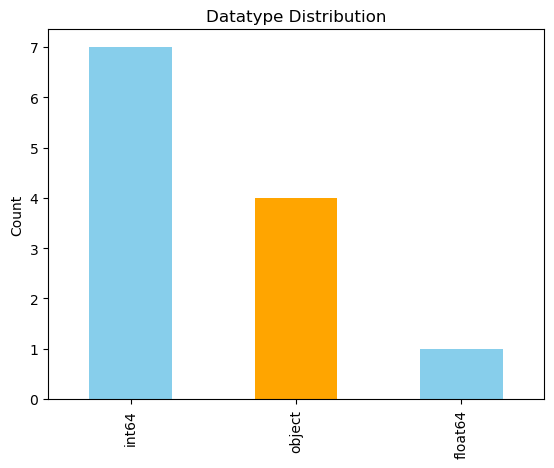

In [3]:
df.dtypes.value_counts().plot(
    kind='bar',
    color=['skyblue', 'orange']
)

plt.title("Datatype Distribution")
plt.ylabel("Count")
plt.show()

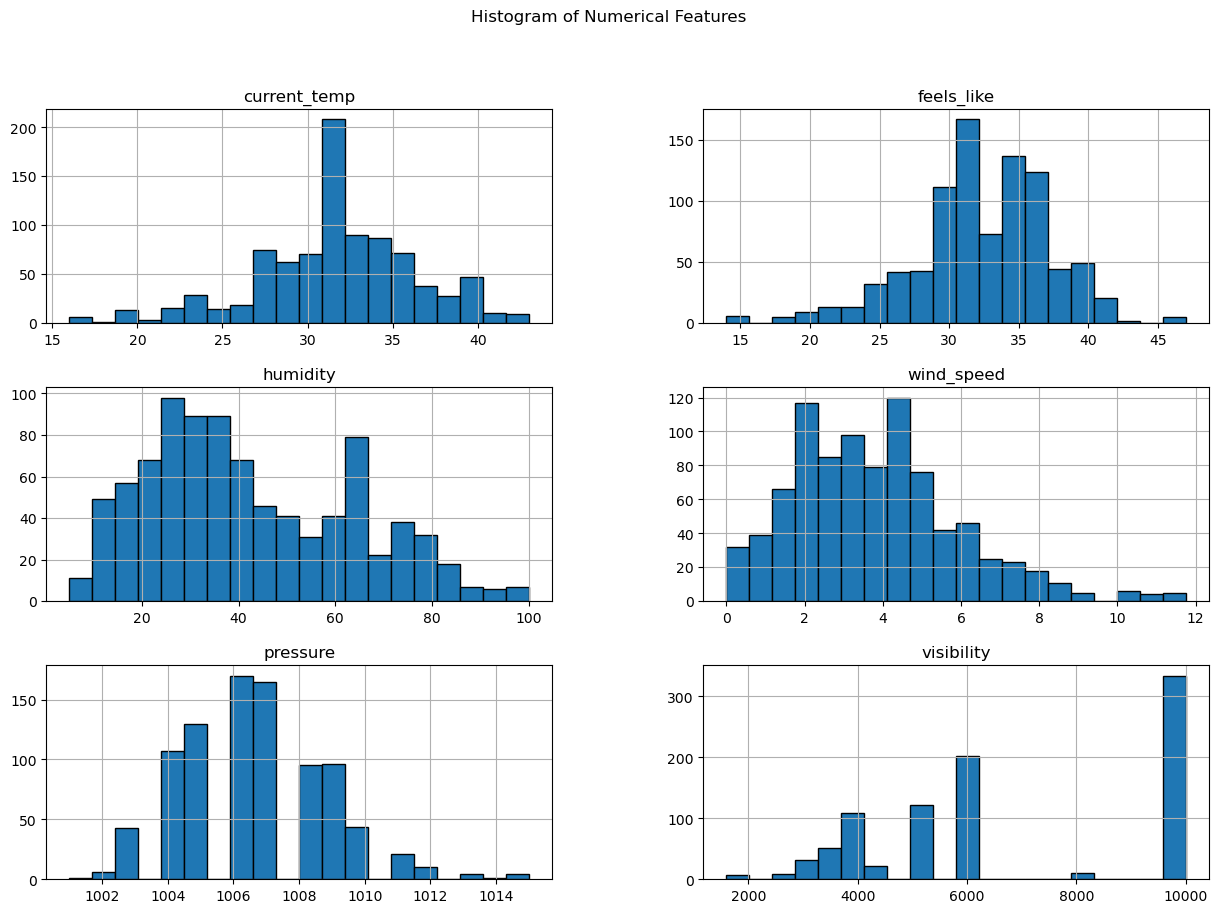

In [4]:
num_cols = [
    'current_temp',
    'feels_like',
    'humidity',
    'wind_speed',
    'pressure',
    'visibility'
]

df[num_cols].hist(
    bins=20,
    figsize=(15,10),
    edgecolor='black'
)

plt.suptitle("Histogram of Numerical Features")
plt.show()

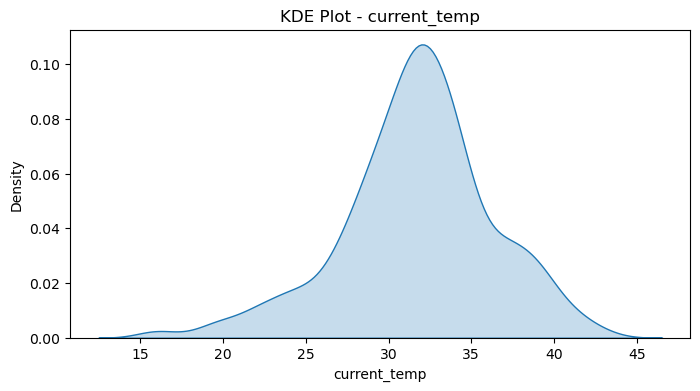

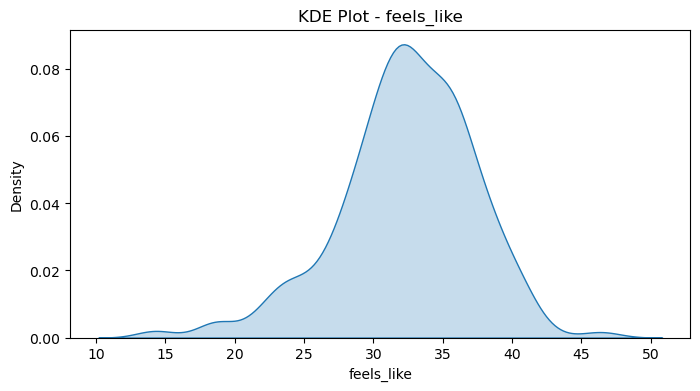

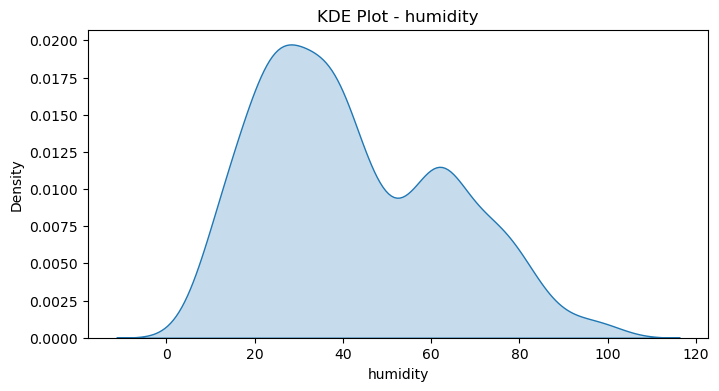

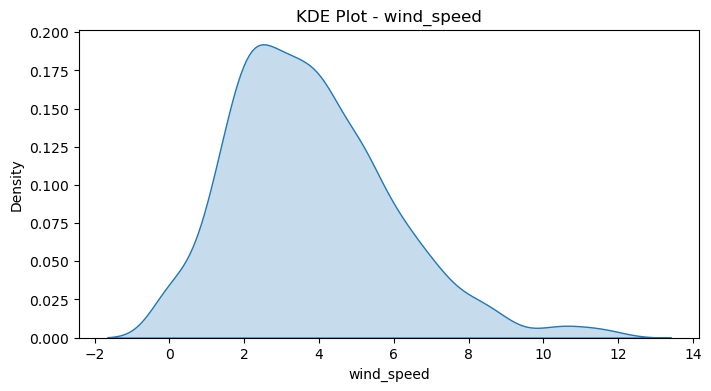

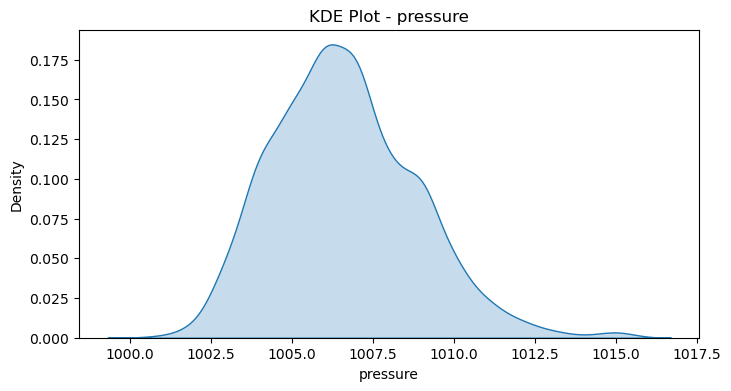

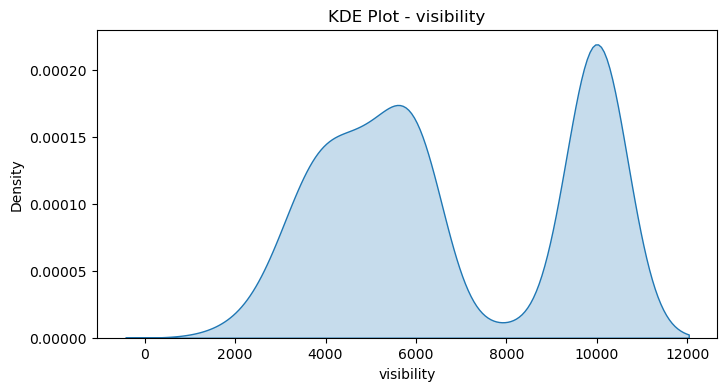

In [5]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    
    sns.kdeplot(df[col], fill=True)
    
    plt.title(f"KDE Plot - {col}")
    plt.show()

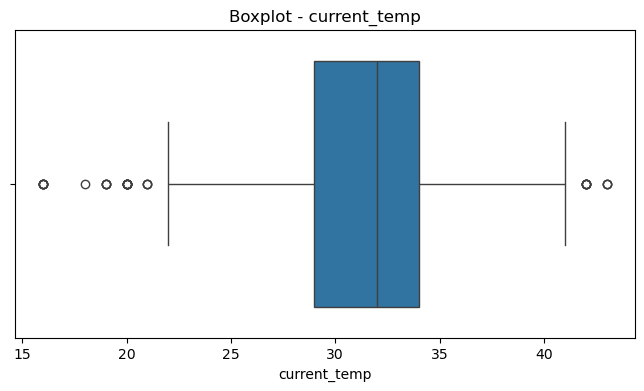

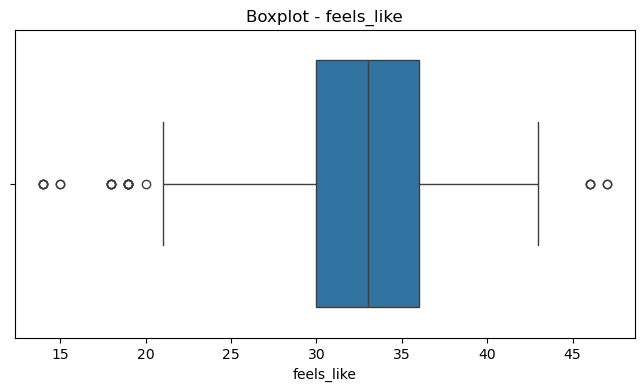

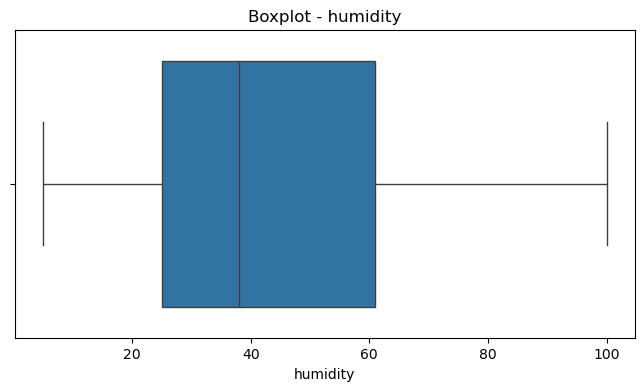

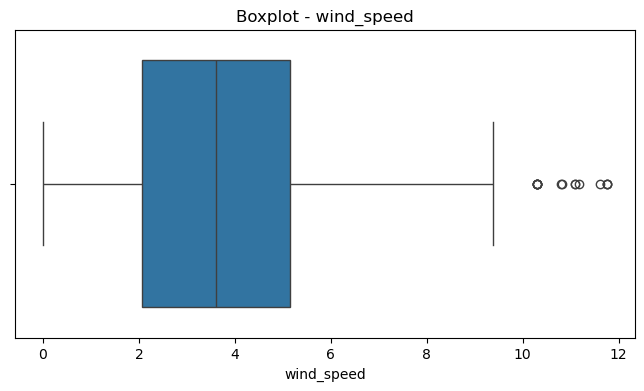

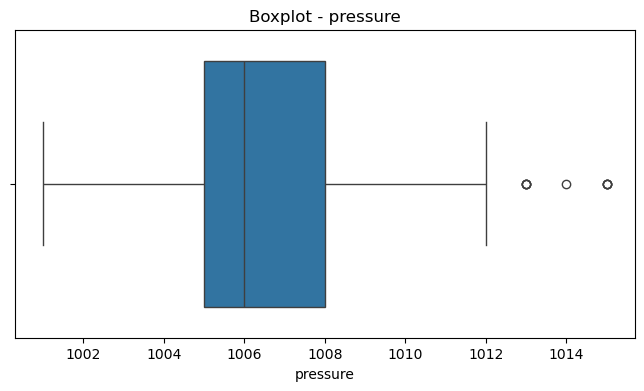

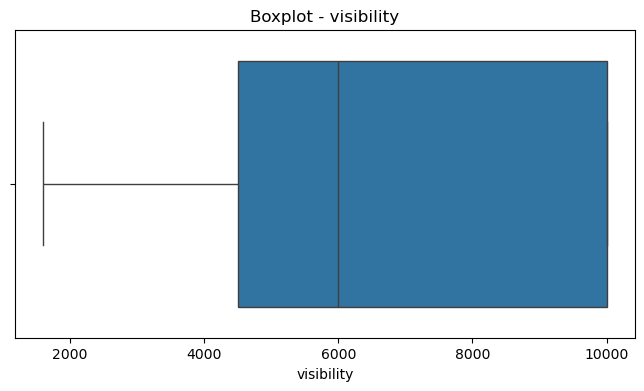

In [6]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot - {col}")
    plt.show()

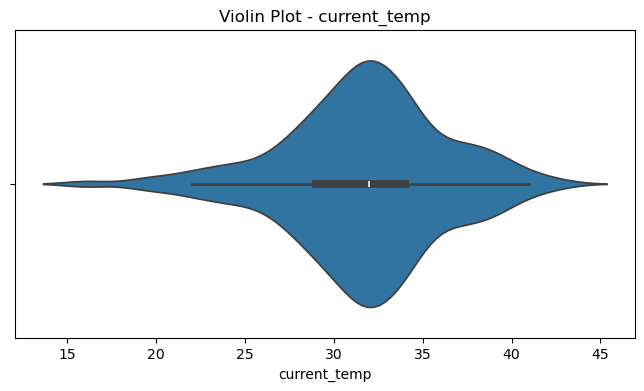

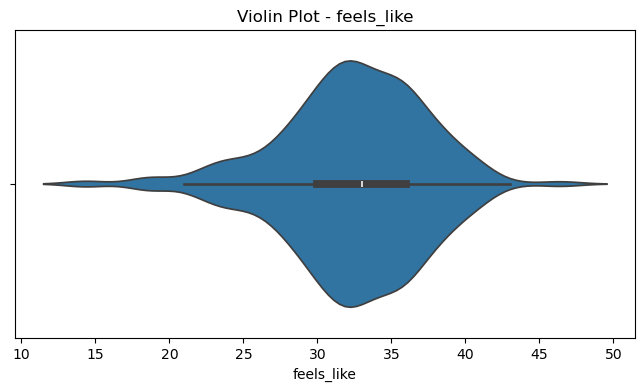

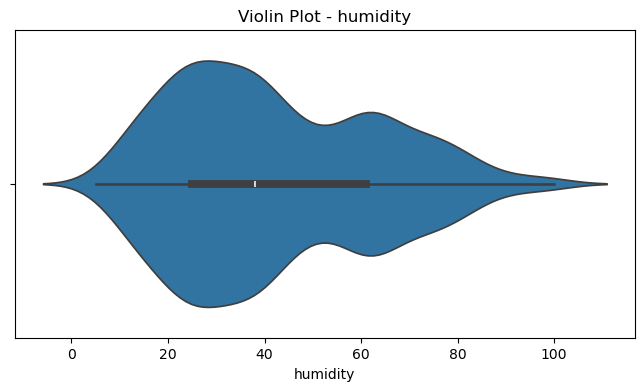

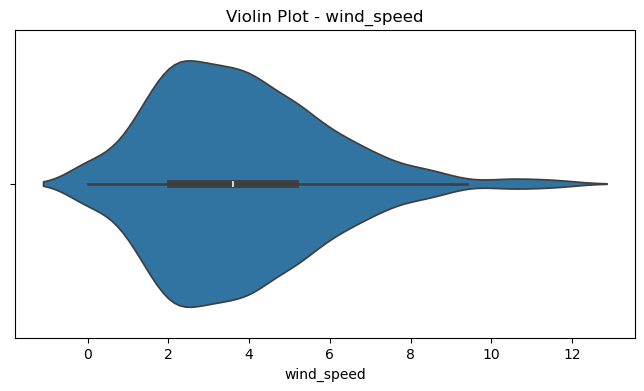

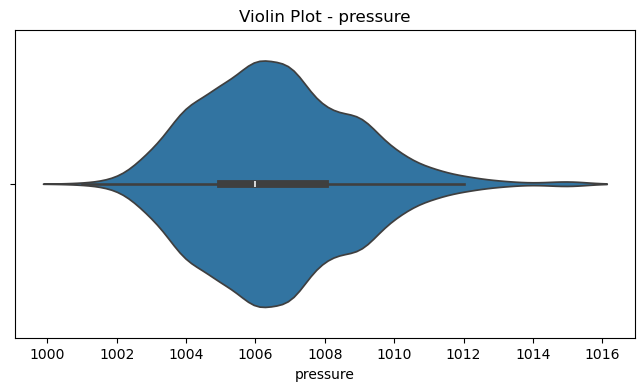

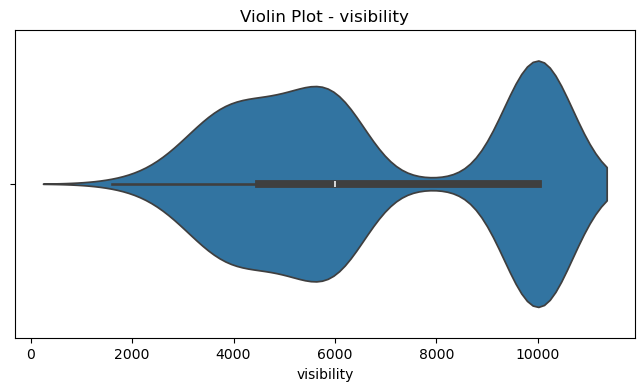

In [7]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    
    sns.violinplot(x=df[col])
    
    plt.title(f"Violin Plot - {col}")
    plt.show()

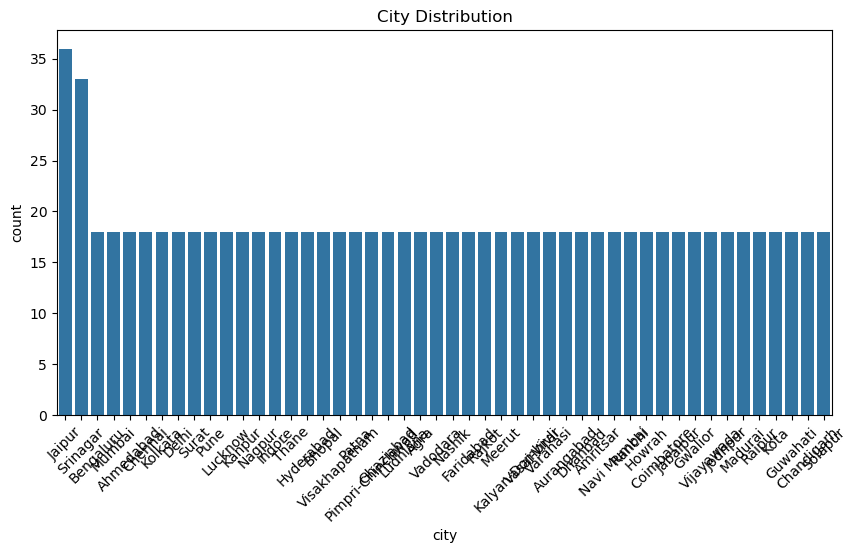

In [16]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='city',
    data=df,
    order=df['city'].value_counts().index
)

plt.title("City Distribution")
plt.xticks(rotation=45)
plt.show()

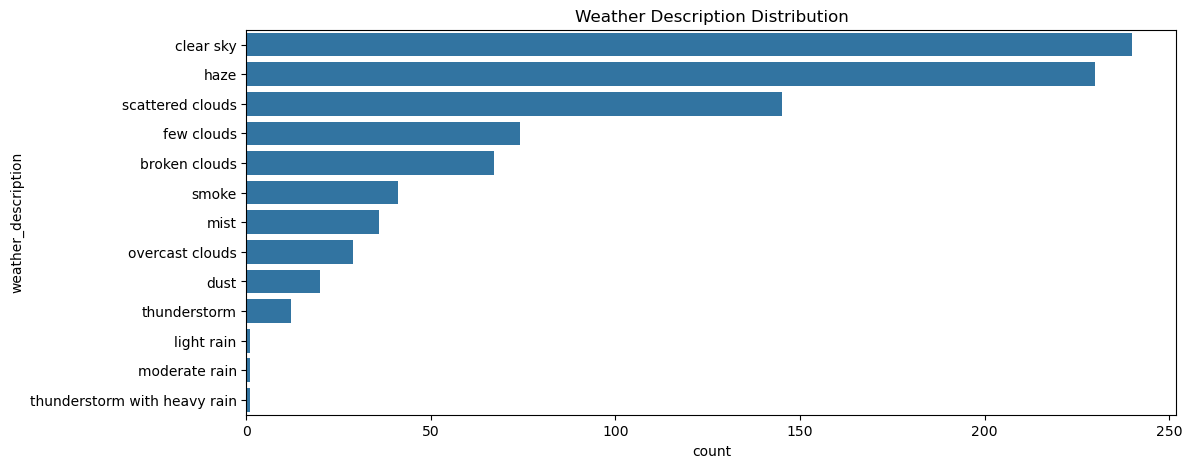

In [17]:
plt.figure(figsize=(12,5))

sns.countplot(
    y='weather_description',
    data=df,
    order=df['weather_description'].value_counts().index
)

plt.title("Weather Description Distribution")
plt.show()

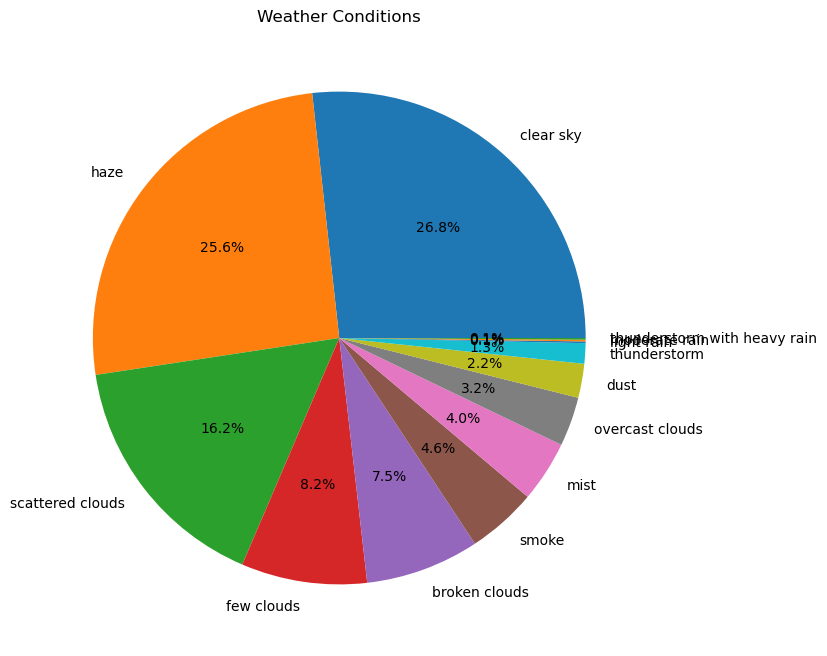

In [18]:
df['weather_description'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.title("Weather Conditions")
plt.ylabel("")
plt.show()

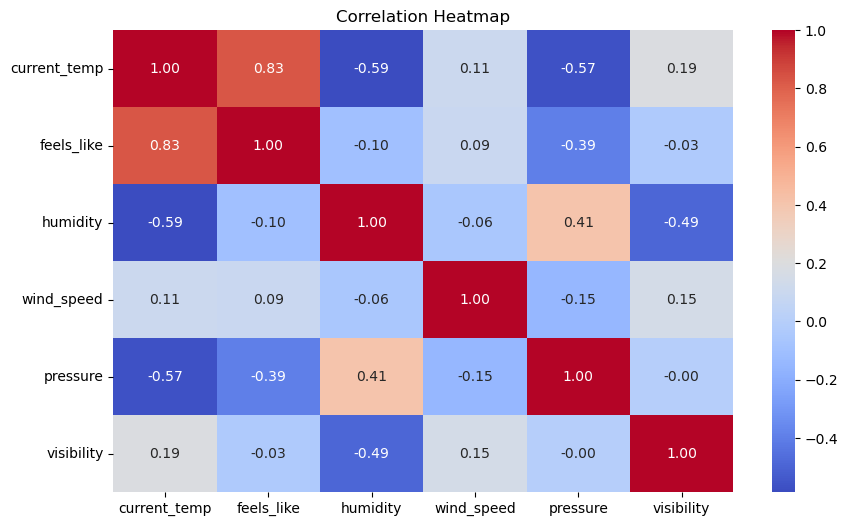

In [19]:
corr = df[num_cols].corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

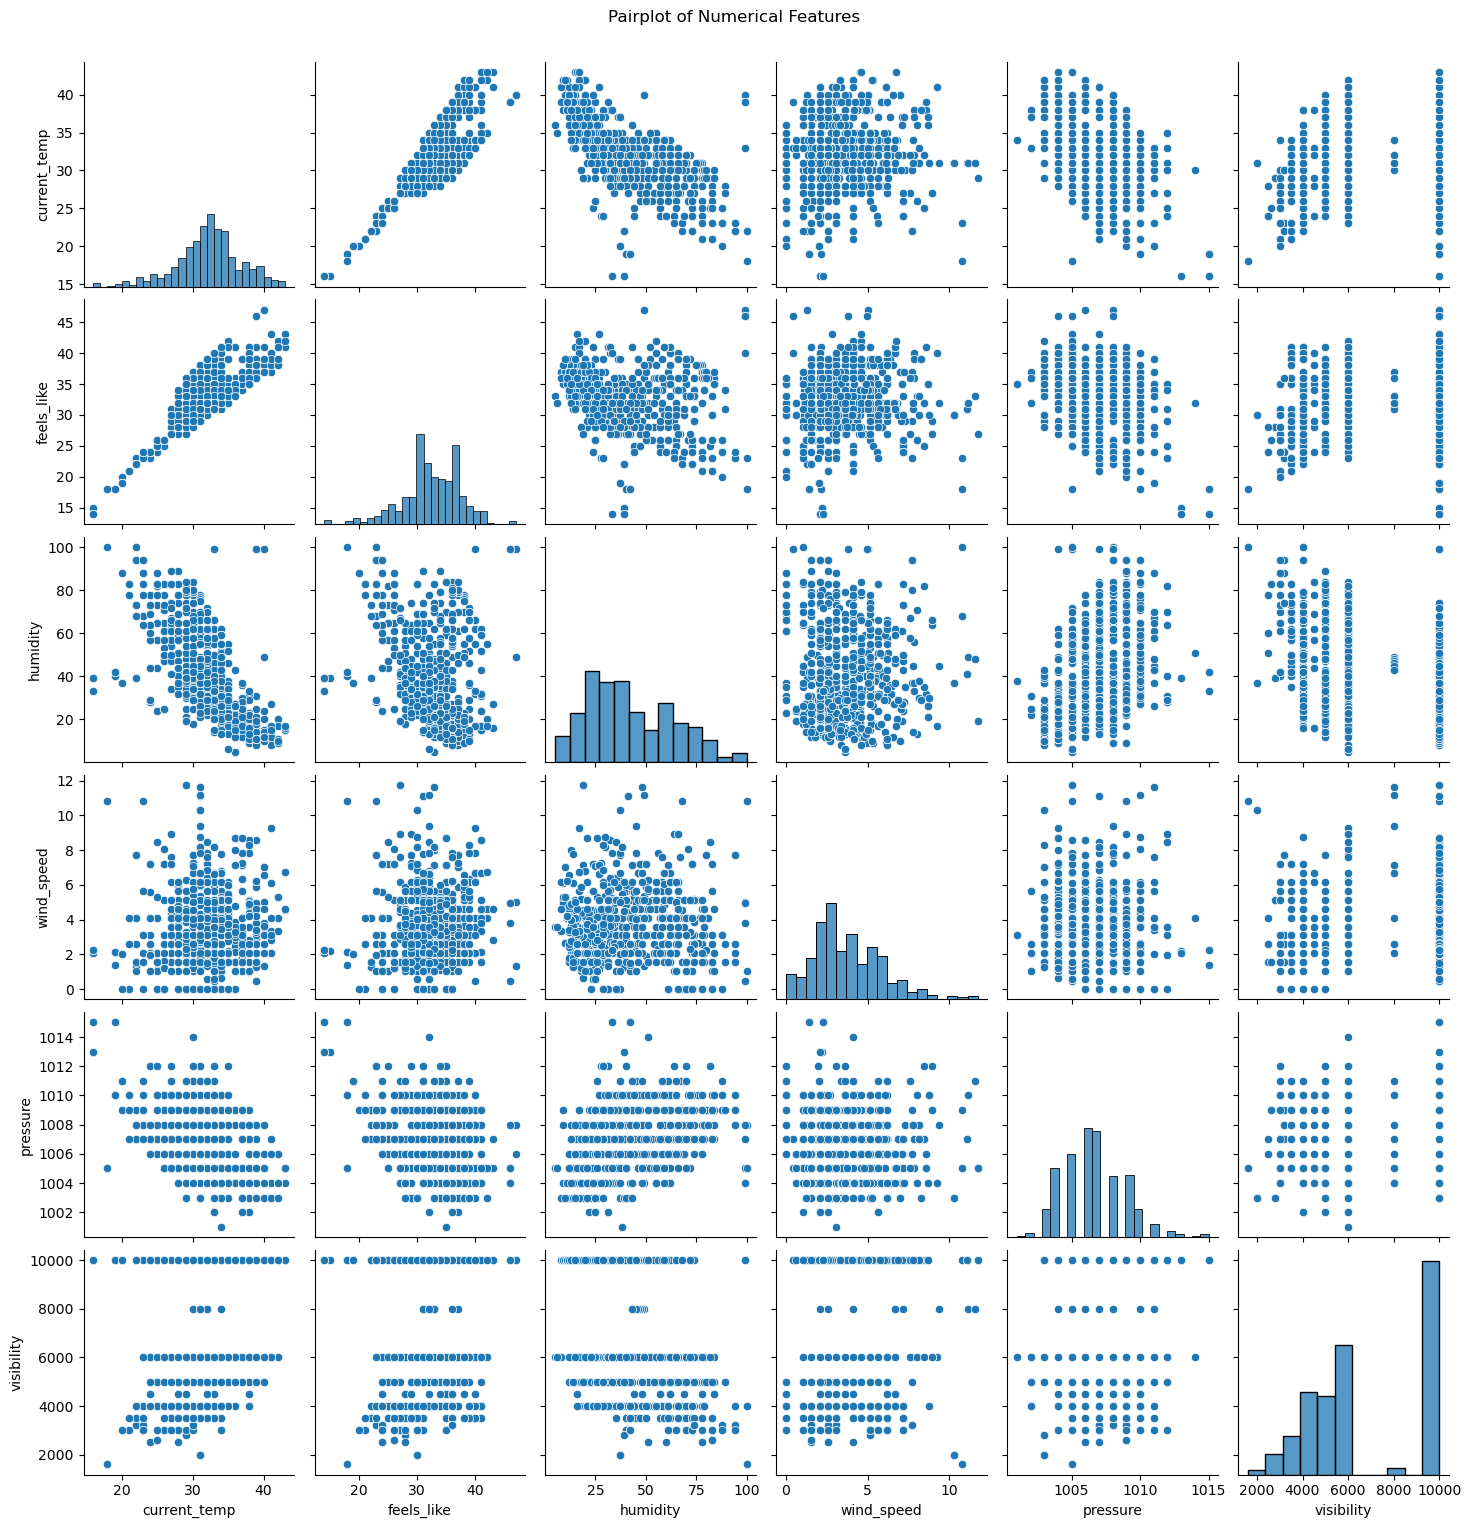

In [20]:
sns.pairplot(df[num_cols])

plt.suptitle("Pairplot of Numerical Features", y=1.02)
plt.show()

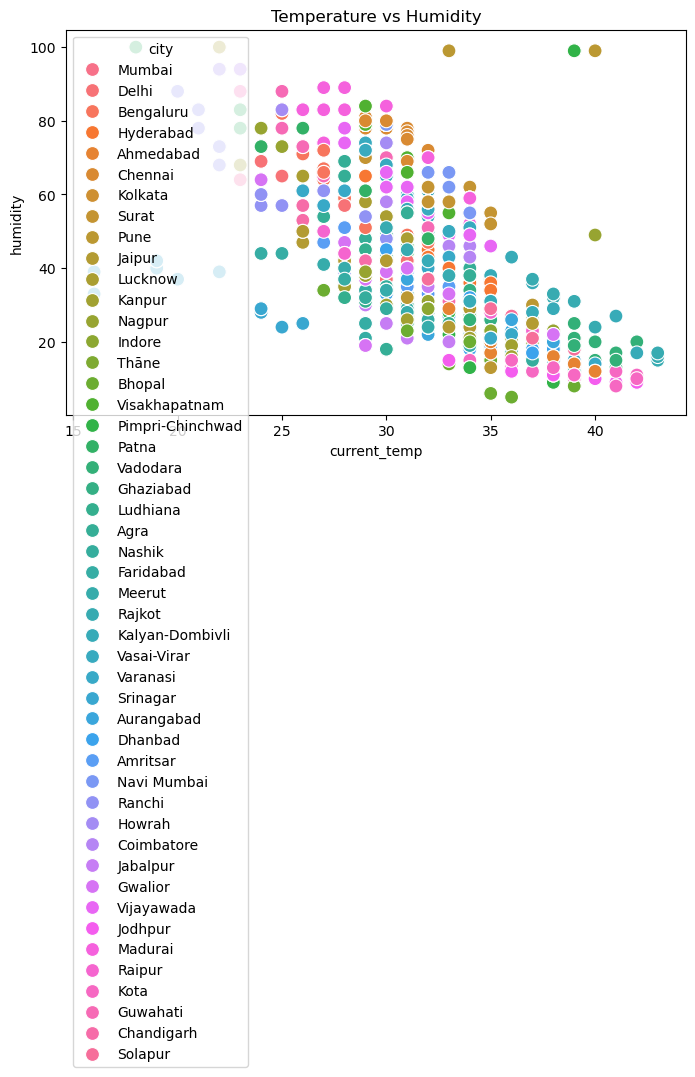

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='current_temp',
    y='humidity',
    hue='city',
    data=df,
    s=100
)

plt.title("Temperature vs Humidity")
plt.show()

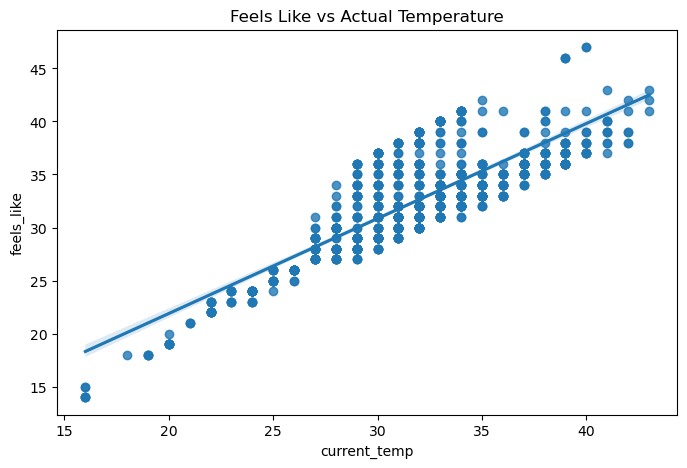

In [22]:
plt.figure(figsize=(8,5))

sns.regplot(
    x='current_temp',
    y='feels_like',
    data=df
)

plt.title("Feels Like vs Actual Temperature")
plt.show()

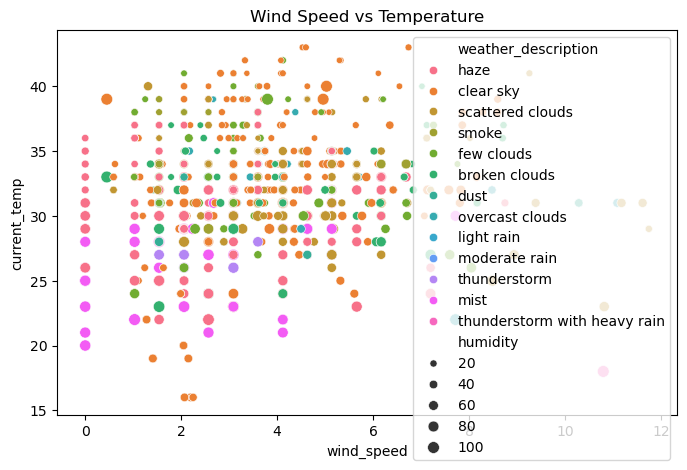

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='wind_speed',
    y='current_temp',
    hue='weather_description',
    size='humidity',
    data=df
)

plt.title("Wind Speed vs Temperature")
plt.show()

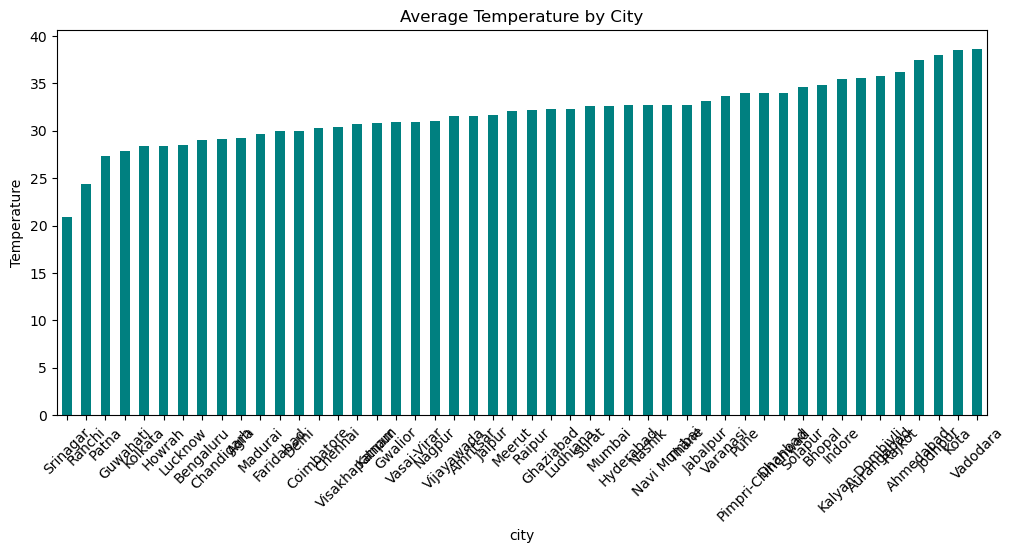

In [24]:
city_temp = df.groupby('city')['current_temp'].mean().sort_values()

plt.figure(figsize=(12,5))

city_temp.plot(
    kind='bar',
    color='teal'
)

plt.title("Average Temperature by City")
plt.ylabel("Temperature")
plt.xticks(rotation=45)
plt.show()

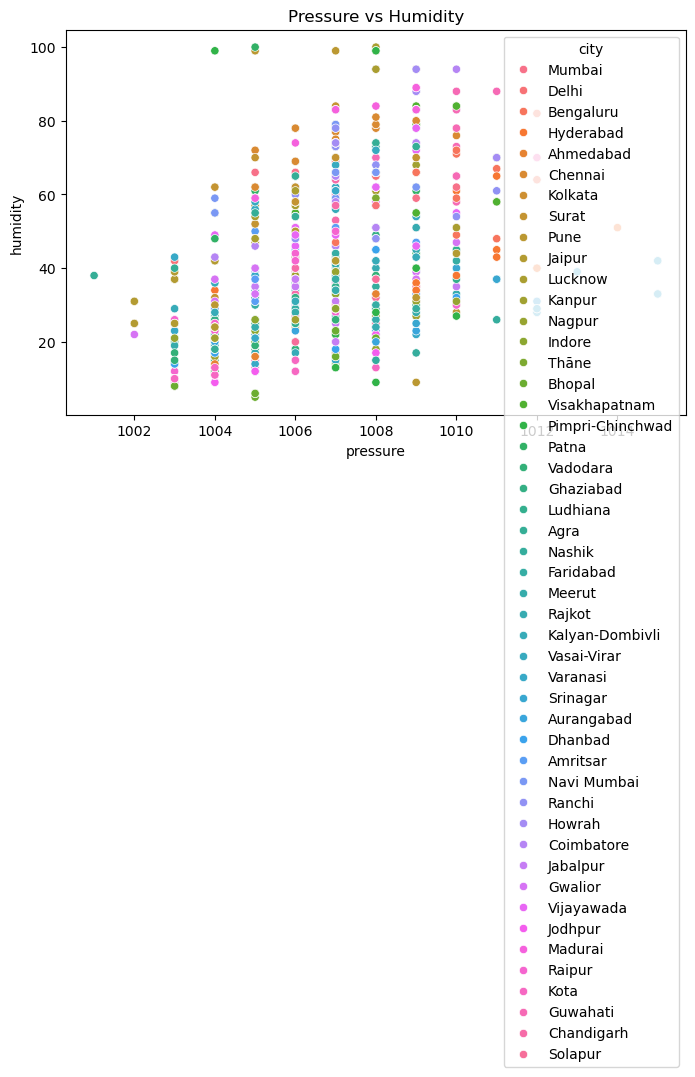

In [25]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='pressure',
    y='humidity',
    hue='city',
    data=df
)

plt.title("Pressure vs Humidity")
plt.show()

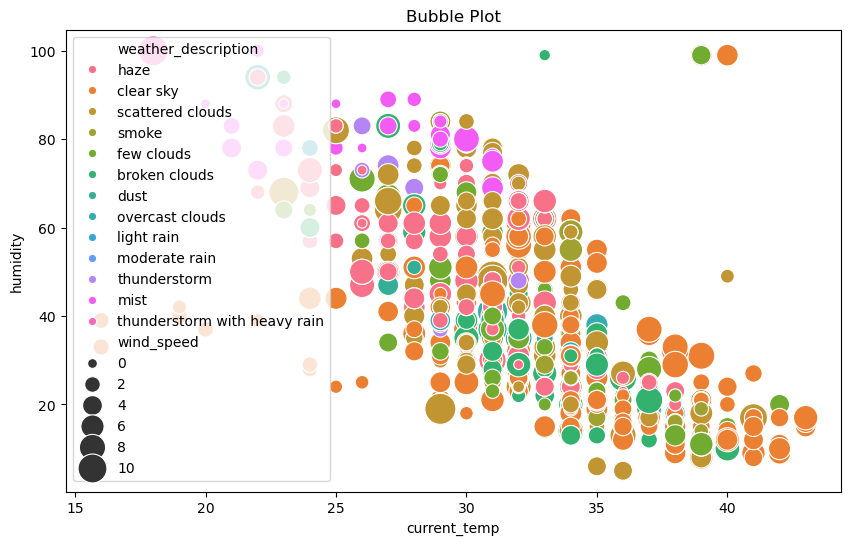

In [26]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='current_temp',
    y='humidity',
    size='wind_speed',
    hue='weather_description',
    data=df,
    sizes=(50,500)
)

plt.title("Bubble Plot")
plt.show()

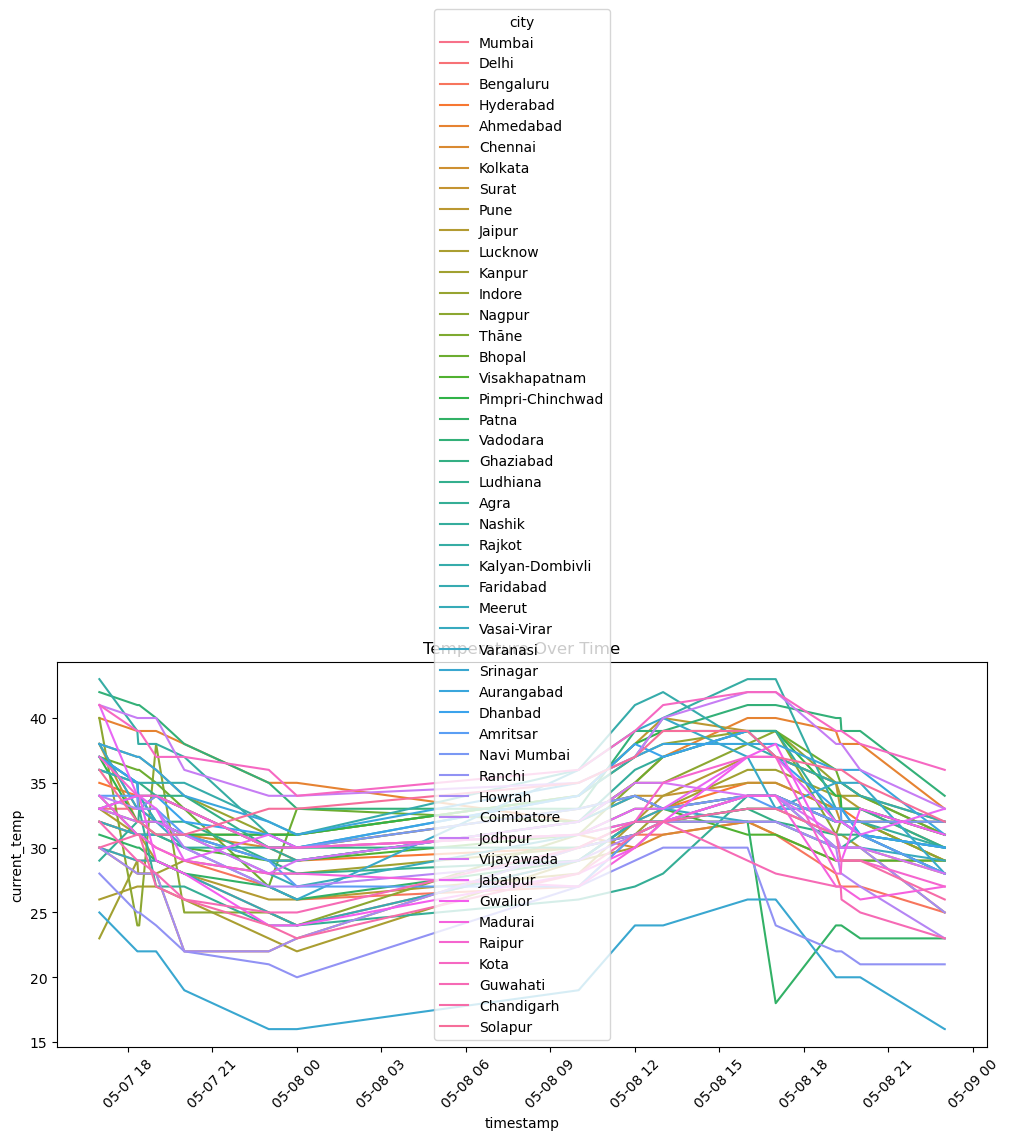

In [27]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

df = df.sort_values('timestamp')

plt.figure(figsize=(12,5))

sns.lineplot(
    x='timestamp',
    y='current_temp',
    hue='city',
    data=df
)

plt.title("Temperature Over Time")
plt.xticks(rotation=45)
plt.show()

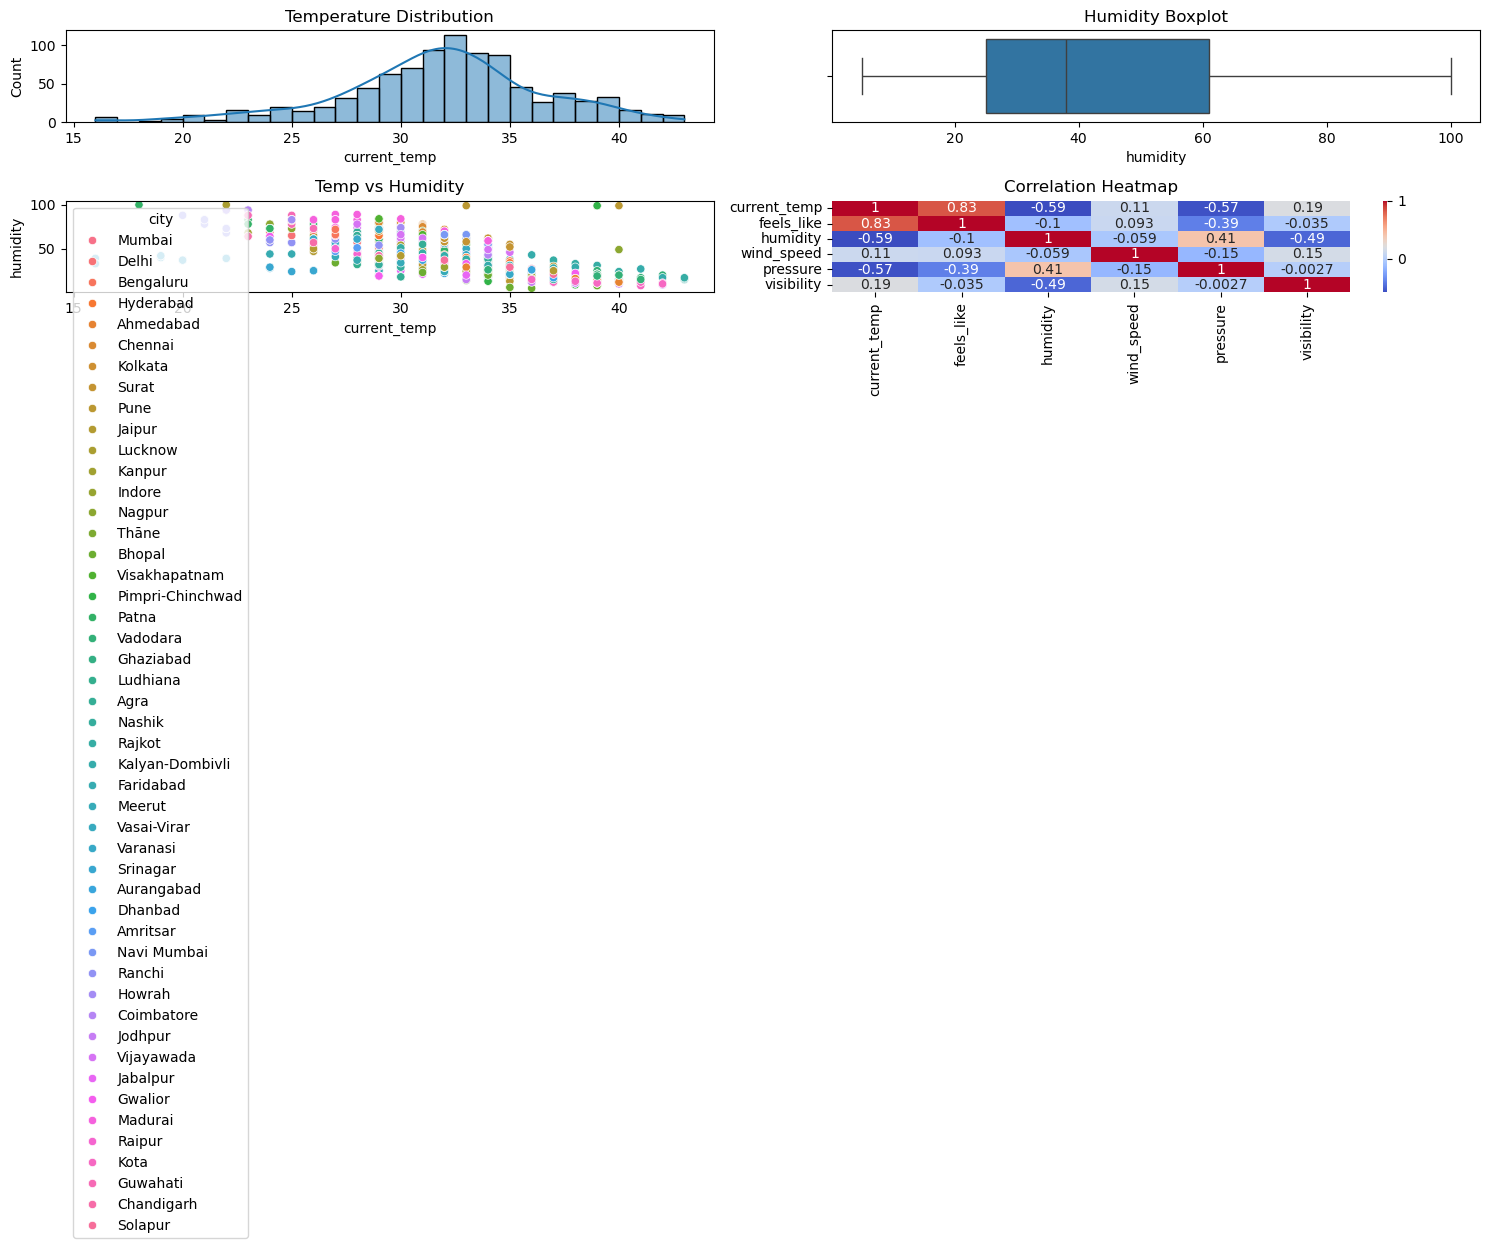

In [28]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

sns.histplot(df['current_temp'], kde=True, ax=axes[0,0])
axes[0,0].set_title("Temperature Distribution")

sns.boxplot(x=df['humidity'], ax=axes[0,1])
axes[0,1].set_title("Humidity Boxplot")

sns.scatterplot(
    x='current_temp',
    y='humidity',
    hue='city',
    data=df,
    ax=axes[1,0]
)
axes[1,0].set_title("Temp vs Humidity")

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    ax=axes[1,1]
)
axes[1,1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()